---
## Parte 3 — Caso real: ciclistas urbanos en Medellín

Hasta aquí trabajamos con una ciudad sintética donde **nosotros** diseñamos los barrios y sus efectos.
Ahora el mismo problema aparece con datos reales.

La base de datos proviene de una encuesta a **810 ciclistas urbanos en Medellín** (Ospina, 2017).
Cada registro es un ciclista con:
- Su **origen de viaje** (punto georreferenciado)
- La **distancia recorrida** `length_km` — la variable Y
- Variables socioeconómicas y del entorno construido

La pregunta es la misma que en la ciudad sintética:

> *¿Un modelo OLS que solo ve características del ciclista comete errores sistemáticos en el espacio?*
---

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-0 — Librerías e imports
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import KNN, DistanceBand
from libpysal import weights
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

np.random.seed(42)
print('✓ Librerías importadas')

✓ Librerías importadas


---
### 3.1 — Cargar los datos y proyectar a metros

Los orígenes están en coordenadas geográficas (EPSG:4326 — grados).
Para calcular distancias en metros necesitamos proyectar a UTM zona 18N (EPSG:32618),
que es el sistema de referencia métrico para Medellín.

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-1 — Cargar shapefile y proyectar
# ─────────────────────────────────────────────────────────────────────────────

# Cargar el shapefile de orígenes
# Ajustar la ruta según donde esté el archivo en su equipo
RUTA_SHP = '../datos/morfologia/Ospina_cyclists_origins_4326_BD.shp'

ciclistas = gpd.read_file(RUTA_SHP)

# Proyectar a UTM 18N — necesario para calcular distancias en metros
ciclistas = ciclistas.to_crs('EPSG:32618')

print(f'Ciclistas cargados: {len(ciclistas)}')
print(f'CRS proyectado: {ciclistas.crs}')
print(f'Variables disponibles: {len(ciclistas.columns) - 1} (+ geometría)')
print()
print('── Variables del modelo ──────────────────────────────────')
print('Y  → length_km   : distancia recorrida en km')
print('X1 → stratum     : estrato socioeconómico del origen (1–6)')
print('X2 → age         : edad del ciclista')
print('X3 → bgender     : género (1=mujer, 0=hombre)')
print('X4 → bLinc       : ingreso bajo (dummy)')
print('X5 → o_cbd       : distancia al CBD desde el origen (km)')
print('X6 → g_elevat    : ganancia de elevación en la ruta (m/m)')
print()
print('── Estadísticas de Y ─────────────────────────────────────')
print(ciclistas['length_km'].describe().round(2))

Ciclistas cargados: 810
CRS proyectado: EPSG:32618
Variables disponibles: 50 (+ geometría)

── Variables del modelo ──────────────────────────────────
Y  → length_km   : distancia recorrida en km
X1 → stratum     : estrato socioeconómico del origen (1–6)
X2 → age         : edad del ciclista
X3 → bgender     : género (1=mujer, 0=hombre)
X4 → bLinc       : ingreso bajo (dummy)
X5 → o_cbd       : distancia al CBD desde el origen (km)
X6 → g_elevat    : ganancia de elevación en la ruta (m/m)

── Estadísticas de Y ─────────────────────────────────────
count    810.00
mean       4.17
std        2.14
min        0.67
25%        2.58
50%        3.83
75%        5.47
max       12.58
Name: length_km, dtype: float64


---
### 3.2 — OLS ciego: el modelo no ve la geografía del origen

Ajustamos un modelo con características del ciclista y del entorno inmediato de su origen.
El modelo **no sabe** en qué zona de la ciudad está el origen — solo ve números.

Si los errores se agrupan espacialmente, el modelo está violando el supuesto de independencia.

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-2 — OLS ciego: ajuste y residuos
# ─────────────────────────────────────────────────────────────────────────────

# Variables del modelo
X_vars = ['stratum', 'age', 'bgender', 'bLinc', 'o_cbd', 'g_elevat']
y_var  = 'length_km'

# Shapefile convierte algunas columnas a string — forzar a numérico
for v in X_vars:
    ciclistas[v] = pd.to_numeric(ciclistas[v], errors='coerce')

# Construir matrices
X = np.column_stack([
    np.ones(len(ciclistas)),
    ciclistas[X_vars].values.astype(float)
])
y = ciclistas[y_var].values

# Estimación OLS
betas, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
ciclistas['y_pred']  = X @ betas
ciclistas['residuo'] = ciclistas[y_var] - ciclistas['y_pred']

# Diagnóstico del modelo
ss_res = np.sum(ciclistas['residuo']**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot

print('─── Coeficientes OLS ───────────────────────────────────────')
nombres = ['Intercepto', 'stratum', 'age', 'bgender (mujer)', 'bLinc (ing. bajo)', 'o_cbd (km al CBD)', 'g_elevat']
for nombre, b in zip(nombres, betas):
    signo = '↑' if b > 0 else '↓'
    print(f'  {nombre:<22}  {b:+.4f}  {signo}')

print(f'\nR² del modelo: {r2:.3f}')
print(f'  → El modelo explica el {r2*100:.1f}% de la variación en length_km')
print(f'  → El {(1-r2)*100:.1f}% restante es ruido... ¿o es geografía?')
print()
print('─── Residuo medio por estrato de origen ────────────────────')
print(ciclistas.groupby('stratum')['residuo'].mean().round(3))
print()
print('→ Si los residuos fueran independientes, no debería haber patrón por estrato.')

─── Coeficientes OLS ───────────────────────────────────────
  Intercepto              +1.7745  ↑
  stratum                 +0.0145  ↑
  age                     -0.0047  ↓
  bgender (mujer)         +0.1126  ↑
  bLinc (ing. bajo)       -0.2133  ↓
  o_cbd (km al CBD)       +0.5006  ↑
  g_elevat                +28.6957  ↑

R² del modelo: 0.434
  → El modelo explica el 43.4% de la variación en length_km
  → El 56.6% restante es ruido... ¿o es geografía?

─── Residuo medio por estrato de origen ────────────────────
stratum
1   -0.112
2    0.023
3   -0.038
4    0.014
5    0.169
6   -0.747
Name: residuo, dtype: float64

→ Si los residuos fueran independientes, no debería haber patrón por estrato.


---
### 3.3 — Mapa de residuos: ¿los errores tienen geografía?

Si el OLS funciona bien, los residuos deben verse como *sal y pimienta* en el mapa — sin manchas.
Si hay manchas, el modelo está cometiendo errores sistemáticos en el espacio.

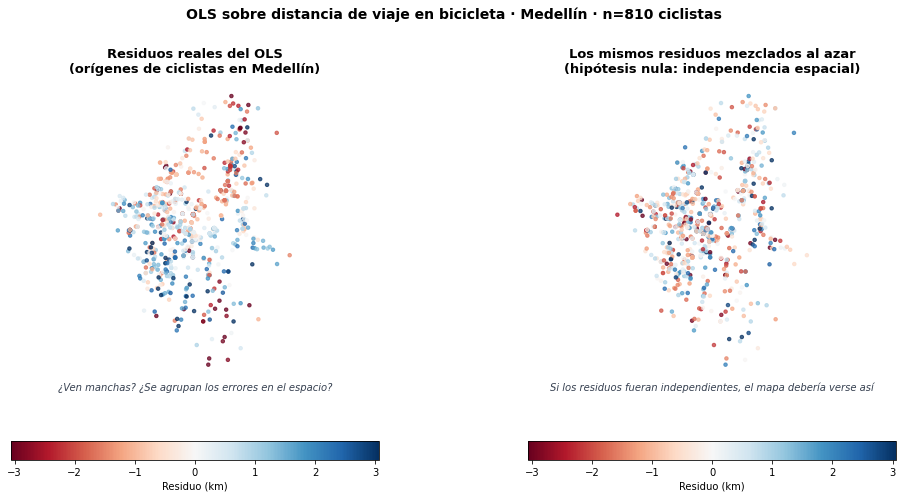


→ Comparar los dos mapas:
   Izquierdo: residuos reales — ¿hay zonas con errores sistemáticamente positivos o negativos?
   Derecho:   residuos aleatorios — así se vería si no hubiera dependencia espacial
   La diferencia visual entre ambos es exactamente lo que el índice de Moran I cuantificará en la Clase 5.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-3 — Mapa de residuos vs. residuos aleatorios
# ─────────────────────────────────────────────────────────────────────────────

# Mezclar residuos al azar — quitar la geografía artificialmente
residuos_random = ciclistas['residuo'].values.copy()
np.random.shuffle(residuos_random)
ciclistas['residuo_random'] = residuos_random

vlim = ciclistas['residuo'].abs().quantile(0.95)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, col, titulo, nota in [
    (axes[0], 'residuo',
     'Residuos reales del OLS\n(orígenes de ciclistas en Medellín)',
     '¿Ven manchas? ¿Se agrupan los errores en el espacio?'),
    (axes[1], 'residuo_random',
     'Los mismos residuos mezclados al azar\n(hipótesis nula: independencia espacial)',
     'Si los residuos fueran independientes, el mapa debería verse así'),
]:
    ciclistas.plot(
        column=col,
        cmap='RdBu',
        ax=ax,
        vmin=-vlim, vmax=vlim,
        markersize=12,
        alpha=0.75,
        legend=True,
        legend_kwds={'label': 'Residuo (km)', 'shrink': 0.6,
                     'orientation': 'horizontal'}
    )
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)
    ax.set_axis_off()
    ax.text(0.5, -0.04, nota,
            transform=ax.transAxes, fontsize=10, style='italic',
            ha='center', color='#374151')

plt.suptitle(
    'OLS sobre distancia de viaje en bicicleta · Medellín · n=810 ciclistas',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_05_ciclistas_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Comparar los dos mapas:')
print('   Izquierdo: residuos reales — ¿hay zonas con errores sistemáticamente positivos o negativos?')
print('   Derecho:   residuos aleatorios — así se vería si no hubiera dependencia espacial')
print('   La diferencia visual entre ambos es exactamente lo que el índice de Moran I cuantificará en la Clase 5.')

---
### 3.3b — El mismo problema visto desde la regresión lineal

El mapa de residuos muestra *dónde* se agrupan los errores en el territorio.
El gráfico de regresión muestra *si* hay un patrón sistemático según el estrato.

Los cuatro paneles replican exactamente lo que vimos con la ciudad sintética:

| Panel | Pregunta |
|---|---|
| Superior izquierdo | ¿Dónde caen los puntos respecto a la diagonal de 45°? |
| Superior derecho | ¿Los residuos parecen aleatorios sin color? |
| Inferior izquierdo | ¿El estrato del origen separa los residuos en bandas? |
| Inferior derecho | ¿El residuo medio varía por estrato? |

> *Si el OLS funcionara igual en todos los estratos, todas las cajas del boxplot
> deberían centrarse en cero — y los colores del scatter deberían mezclarse al azar.*

─── Residuo medio por estrato ──────────────────────────────────────
  Estrato 1 (n= 24): -0.112 km  (-112 m)
  Estrato 2 (n=117): +0.023 km  (+23 m)
  Estrato 3 (n=253): -0.038 km  (-38 m)
  Estrato 4 (n=243): +0.014 km  (+14 m)
  Estrato 5 (n=148): +0.169 km  (+169 m)
  Estrato 6 (n= 25): -0.747 km  (-747 m)

→ Residuos positivos: el modelo subestima la distancia recorrida.
→ Residuos negativos: el modelo sobreestima la distancia recorrida.
→ Si los medios difieren entre estratos, el estrato no captura
  toda la variación geográfica — hay efectos de lugar adicionales.


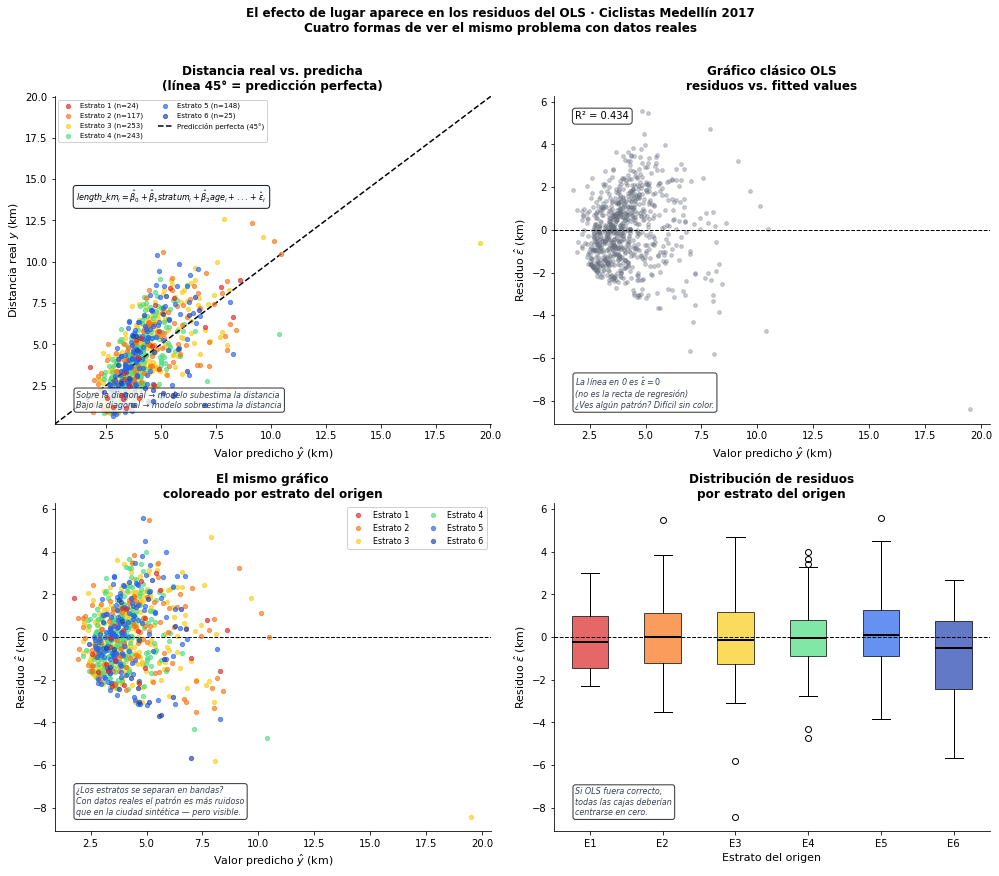

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-3b — El efecto de estrato visto desde la regresión lineal
# Replica los 4 paneles de la ciudad sintética con datos reales de ciclistas
# ─────────────────────────────────────────────────────────────────────────────

# Paleta por estrato — de rojo (bajo) a azul (alto)
colores_estrato = {
    1: '#dc2626',   # rojo — bajo-bajo
    2: '#f97316',   # naranja
    3: '#facc15',   # amarillo
    4: '#4ade80',   # verde
    5: '#2563eb',   # azul
    6: '#1e40af',   # azul oscuro — alto
}
zorder_est = {1: 4, 2: 3, 3: 2, 4: 2, 5: 3, 6: 4}

y_real_c     = ciclistas[y_var].values
y_pred_c     = ciclistas['y_pred'].values
residuos_c   = ciclistas['residuo'].values
estratos_c   = pd.to_numeric(ciclistas['stratum'], errors='coerce').values

r2_c = 1 - np.sum(residuos_c**2) / np.sum((y_real_c - y_real_c.mean())**2)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax0, ax1 = axes[0, 0], axes[0, 1]
ax2, ax3 = axes[1, 0], axes[1, 1]

# ── Panel 0: y_real vs. y_pred — línea de 45° ───────────────────────────────
lim_min = min(y_real_c.min(), y_pred_c.min()) - 0.5
lim_max = max(y_real_c.max(), y_pred_c.max()) + 0.5

for est, color in colores_estrato.items():
    mask = estratos_c == est
    if mask.sum() == 0:
        continue
    ax0.scatter(y_pred_c[mask], y_real_c[mask],
                alpha=0.65, s=18, color=color,
                label=f'Estrato {est} (n={mask.sum()})',
                zorder=zorder_est[est])

ax0.plot([lim_min, lim_max], [lim_min, lim_max],
         color='black', linewidth=1.5, linestyle='--',
         label='Predicción perfecta (45°)')
ax0.set_xlim(lim_min, lim_max)
ax0.set_ylim(lim_min, lim_max)
ax0.set_xlabel('Valor predicho $\\hat{y}$ (km)', fontsize=11)
ax0.set_ylabel('Distancia real $y$ (km)', fontsize=11)
ax0.set_title('Distancia real vs. predicha\n(línea 45° = predicción perfecta)',
              fontsize=12, fontweight='bold')
ax0.legend(fontsize=7, framealpha=0.9, loc='upper left', ncol=2)
ax0.text(0.05, 0.68,
         '$length\_km_i = \\hat{\\beta}_0 + \\hat{\\beta}_1 stratum_i'
         ' + \\hat{\\beta}_2 age_i + ... + \\hat{\\varepsilon}_i$',
         transform=ax0.transAxes, fontsize=8,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f9fafb', alpha=0.9))
ax0.text(0.05, 0.05,
         'Sobre la diagonal → modelo subestima la distancia\n'
         'Bajo la diagonal → modelo sobreestima la distancia',
         transform=ax0.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 1: residuos vs. fitted values SIN color ───────────────────────────
ax1.scatter(y_pred_c, residuos_c, alpha=0.35, s=14, color='#6b7280')
ax1.axhline(0, color='black', linewidth=1, linestyle='--')
ax1.set_xlabel('Valor predicho $\\hat{y}$ (km)', fontsize=11)
ax1.set_ylabel('Residuo $\\hat{\\varepsilon}$ (km)', fontsize=11)
ax1.set_title('Gráfico clásico OLS\nresiduos vs. fitted values',
              fontsize=12, fontweight='bold')
ax1.text(0.05, 0.93, f'R² = {r2_c:.3f}', transform=ax1.transAxes, fontsize=10,
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax1.text(0.05, 0.05,
         'La línea en 0 es $\\hat{\\varepsilon}=0$\n'
         '(no es la recta de regresión)\n'
         '¿Ves algún patrón? Difícil sin color.',
         transform=ax1.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 2: residuos vs. fitted values CON color de estrato ────────────────
for est, color in colores_estrato.items():
    mask = estratos_c == est
    if mask.sum() == 0:
        continue
    ax2.scatter(y_pred_c[mask], residuos_c[mask],
                alpha=0.65, s=18, color=color,
                label=f'Estrato {est}', zorder=zorder_est[est])
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Valor predicho $\\hat{y}$ (km)', fontsize=11)
ax2.set_ylabel('Residuo $\\hat{\\varepsilon}$ (km)', fontsize=11)
ax2.set_title('El mismo gráfico\ncoloreado por estrato del origen',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=8, loc='upper right', framealpha=0.9, ncol=2)
ax2.text(0.05, 0.05,
         '¿Los estratos se separan en bandas?\n'
         'Con datos reales el patrón es más ruidoso\n'
         'que en la ciudad sintética — pero visible.',
         transform=ax2.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# ── Panel 3: boxplot de residuos por estrato ─────────────────────────────────
estratos_orden = [1, 2, 3, 4, 5, 6]
datos_box   = [residuos_c[estratos_c == e] for e in estratos_orden]
colores_box = [colores_estrato[e] for e in estratos_orden]

bp = ax3.boxplot(datos_box, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax3.axhline(0, color='black', linewidth=1, linestyle='--')
ax3.set_xticks(range(1, 7))
ax3.set_xticklabels([f'E{e}' for e in estratos_orden], fontsize=10)
ax3.set_xlabel('Estrato del origen', fontsize=11)
ax3.set_ylabel('Residuo $\\hat{\\varepsilon}$ (km)', fontsize=11)
ax3.set_title('Distribución de residuos\npor estrato del origen',
              fontsize=12, fontweight='bold')
ax3.text(0.05, 0.05,
         'Si OLS fuera correcto,\ntodas las cajas deberían\ncentrarse en cero.',
         transform=ax3.transAxes, fontsize=8, style='italic', color='#374151',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

print('─── Residuo medio por estrato ──────────────────────────────────────')
for e in estratos_orden:
    datos = residuos_c[estratos_c == e]
    if len(datos) > 0:
        print(f'  Estrato {e} (n={len(datos):3d}): {datos.mean():+.3f} km  '
              f'({datos.mean()*1000:+.0f} m)')
print()
print('→ Residuos positivos: el modelo subestima la distancia recorrida.')
print('→ Residuos negativos: el modelo sobreestima la distancia recorrida.')
print('→ Si los medios difieren entre estratos, el estrato no captura')
print('  toda la variación geográfica — hay efectos de lugar adicionales.')

plt.suptitle(
    'El efecto de lugar aparece en los residuos del OLS · Ciclistas Medellín 2017\n'
    'Cuatro formas de ver el mismo problema con datos reales',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_03b_ciclistas_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 3.4 — Mapa del contexto: estrato del origen

El modelo usa el estrato como variable numérica. Veamos su distribución espacial
junto a los residuos para ver si el OLS está perdiendo algo en el espacio.

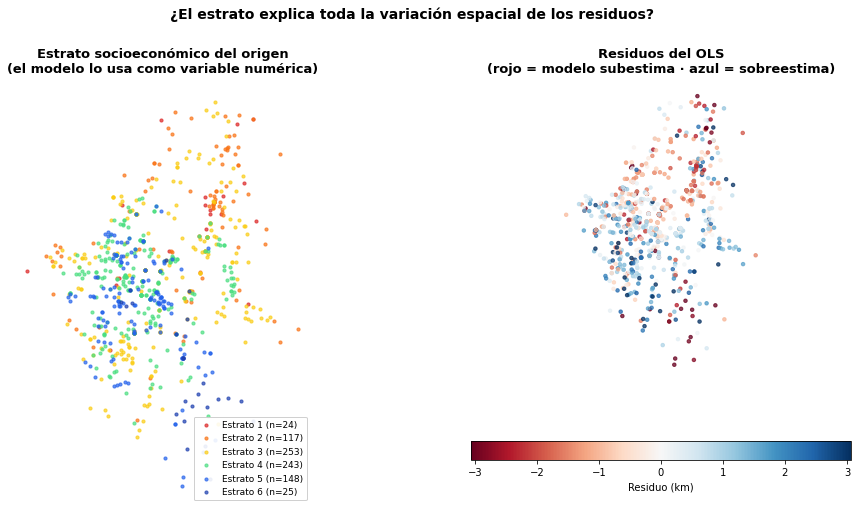


→ Si el estrato capturara toda la geografía, los residuos no mostrarían patrón espacial.
→ ¿Hay zonas donde el modelo falla sistemáticamente aunque el estrato es el mismo?
   Eso indicaría que hay efectos espaciales que el OLS no puede ver.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-4 — Mapa de estrato del origen y residuos lado a lado
# ─────────────────────────────────────────────────────────────────────────────

colores_estrato = {
    1: '#dc2626',  # rojo — bajo-bajo
    2: '#f97316',  # naranja
    3: '#facc15',  # amarillo
    4: '#4ade80',  # verde claro
    5: '#2563eb',  # azul
    6: '#1e40af',  # azul oscuro — alto
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Panel izquierdo: estrato del origen
ax1 = axes[0]
for estrato, color in colores_estrato.items():
    sub = ciclistas[ciclistas['stratum'] == estrato]
    sub.plot(ax=ax1, color=color, markersize=10, alpha=0.7, label=f'Estrato {estrato} (n={len(sub)})')
ax1.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax1.set_title('Estrato socioeconómico del origen\n(el modelo lo usa como variable numérica)',
              fontsize=13, fontweight='bold', pad=10)
ax1.set_axis_off()

# Panel derecho: residuos
ax2 = axes[1]
ciclistas.plot(
    column='residuo', cmap='RdBu', ax=ax2,
    vmin=-vlim, vmax=vlim,
    markersize=12, alpha=0.75,
    legend=True,
    legend_kwds={'label': 'Residuo (km)', 'shrink': 0.6,
                 'orientation': 'horizontal'}
)
ax2.set_title('Residuos del OLS\n(rojo = modelo subestima · azul = sobreestima)',
              fontsize=13, fontweight='bold', pad=10)
ax2.set_axis_off()

plt.suptitle(
    '¿El estrato explica toda la variación espacial de los residuos?',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_06_ciclistas_estrato_residuos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ Si el estrato capturara toda la geografía, los residuos no mostrarían patrón espacial.')
print('→ ¿Hay zonas donde el modelo falla sistemáticamente aunque el estrato es el mismo?')
print('   Eso indicaría que hay efectos espaciales que el OLS no puede ver.')

---
### 3.5 — Construir W para puntos

Aquí aparece la primera diferencia importante respecto a la ciudad sintética:

| Ciudad sintética | Ciclistas reales |
|---|---|
| Polígonos (manzanas) | Puntos (orígenes) |
| Vecindad = borde compartido | Vecindad = proximidad en el espacio |
| Queen y Rook tienen sentido | Queen y Rook **no aplican** |
| KNN y DistanceBand también funcionan | KNN y DistanceBand son las opciones naturales |

**¿Por qué Queen no aplica para puntos?**
Queen requiere que los polígonos compartan un borde o vértice.
Los puntos son geometrías sin área — no tienen bordes, no pueden ser contiguos.
Para puntos, la vecindad debe definirse por **distancia** o por **rango de cercanía**.

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-5 — Construir dos W para los orígenes de ciclistas
# ─────────────────────────────────────────────────────────────────────────────

# W 1 — KNN k=5: los 5 ciclistas con origen más cercano
# Justificación: cada ciclista es influido por el entorno inmediato de su origen,
# aproximado por los 5 orígenes más próximos independientemente de su distancia exacta.
w_knn = KNN.from_dataframe(ciclistas, k=5)
w_knn.transform = 'r'

# W 2 — DistanceBand 1000m: todos los ciclistas con origen a menos de 1 km
# Justificación: 1 km es el radio peatonal estándar (NACTO) —
# el entorno que un ciclista percibe y evalúa desde su punto de partida.
w_dist = DistanceBand.from_dataframe(ciclistas, threshold=1000)
w_dist.transform = 'r'

print('─── Diagnóstico de las W ────────────────────────────────────')
print(f'KNN k=5')
print(f'  Vecinos promedio : {w_knn.mean_neighbors:.1f} (fijo por construcción)')
print(f'  Aislados         : 0 (KNN garantiza siempre k vecinos)')
print()
print(f'DistanceBand 1000m')
print(f'  Vecinos promedio : {w_dist.mean_neighbors:.1f}')
aislados = sum(1 for v in w_dist.cardinalities.values() if v == 0)
print(f'  Aislados         : {aislados} (ciclistas sin otro origen a menos de 1 km)')
print()
print('→ KNN garantiza conectividad total — todos tienen exactamente 5 vecinos.')
print('→ DistanceBand tiene interpretación urbana directa — radio peatonal de 1 km.')
print('→ Para el análisis exploratorio de esta clase usaremos KNN.')
print('  En la Clase 5, cada equipo justificará cuál W es más apropiada para su proyecto.')

('WARNING: ', 648, ' is an island (no neighbors)')
─── Diagnóstico de las W ────────────────────────────────────
KNN k=5
  Vecinos promedio : 5.0 (fijo por construcción)
  Aislados         : 0 (KNN garantiza siempre k vecinos)

DistanceBand 1000m
  Vecinos promedio : 51.0
  Aislados         : 1 (ciclistas sin otro origen a menos de 1 km)

→ KNN garantiza conectividad total — todos tienen exactamente 5 vecinos.
→ DistanceBand tiene interpretación urbana directa — radio peatonal de 1 km.
→ Para el análisis exploratorio de esta clase usaremos KNN.
  En la Clase 5, cada equipo justificará cuál W es más apropiada para su proyecto.


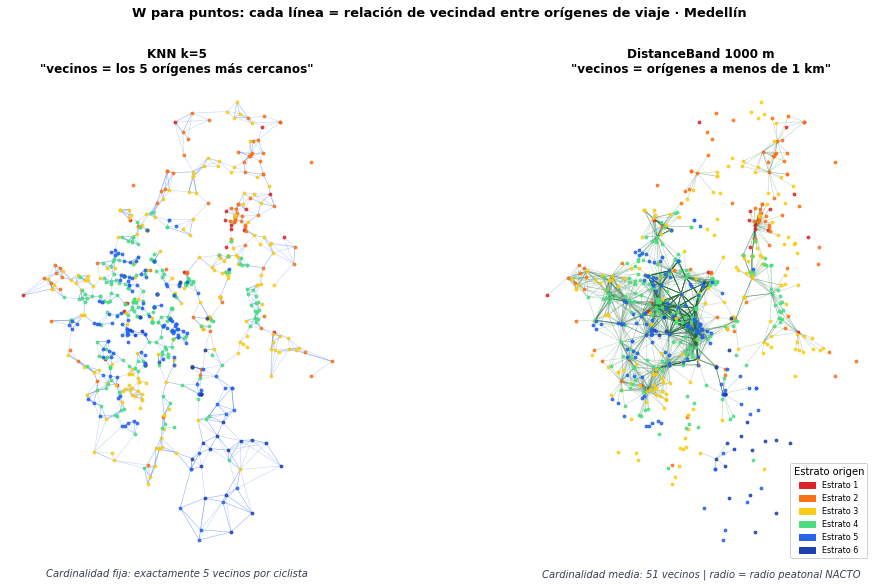


→ A diferencia de las manzanas, aquí las conexiones cruzan el espacio libremente.
→ KNN conecta cada origen con los 5 más cercanos — la red es homogénea en densidad.
→ DistanceBand conecta todos los orígenes dentro de 1 km — la densidad varía según la concentración de ciclistas.


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-6 — Mapa de conectividad: las dos W sobre los orígenes
# ─────────────────────────────────────────────────────────────────────────────

def dibujar_conexiones_puntos(ax, gdf, w, color='#2563EB', alpha=0.25, lw=0.6, max_lineas=3000):
    """Dibuja líneas entre orígenes vecinos. Limita el total para no saturar el mapa."""
    coords = [(g.x, g.y) for g in gdf.geometry]
    lineas = 0
    for i, vecinos in w.neighbors.items():
        xi, yi = coords[i]
        for j in vecinos:
            if lineas >= max_lineas:
                break
            xj, yj = coords[j]
            ax.plot([xi, xj], [yi, yj], color=color,
                    alpha=alpha, linewidth=lw, zorder=1)
            lineas += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

configs = [
    (w_knn,  'KNN k=5\n"vecinos = los 5 orígenes más cercanos"',
     f'Cardinalidad fija: exactamente 5 vecinos por ciclista', '#2563EB'),
    (w_dist, 'DistanceBand 1000 m\n"vecinos = orígenes a menos de 1 km"',
     f'Cardinalidad media: {w_dist.mean_neighbors:.0f} vecinos | radio = radio peatonal NACTO', '#166534'),
]

for ax, (w, titulo, subtitulo, color) in zip(axes, configs):
    # Líneas de conexión
    dibujar_conexiones_puntos(ax, ciclistas, w, color=color)
    # Puntos de origen coloreados por estrato
    for estrato, col_est in colores_estrato.items():
        sub = ciclistas[ciclistas['stratum'] == estrato]
        sub.plot(ax=ax, color=col_est, markersize=8, alpha=0.85, zorder=3)
    ax.set_title(titulo, fontsize=12, fontweight='bold', pad=8)
    ax.set_axis_off()
    ax.text(0.5, -0.03, subtitulo,
            transform=ax.transAxes, fontsize=10, ha='center',
            color='#374151', style='italic')

# Leyenda de estratos
patches = [mpatches.Patch(color=c, label=f'Estrato {e}')
           for e, c in colores_estrato.items()]
axes[1].legend(handles=patches, loc='lower right', fontsize=8,
               framealpha=0.9, title='Estrato origen')

plt.suptitle(
    'W para puntos: cada línea = relación de vecindad entre orígenes de viaje · Medellín',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_07_ciclistas_W.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n→ A diferencia de las manzanas, aquí las conexiones cruzan el espacio libremente.')
print('→ KNN conecta cada origen con los 5 más cercanos — la red es homogénea en densidad.')
print('→ DistanceBand conecta todos los orígenes dentro de 1 km — la densidad varía según la concentración de ciclistas.')

---
### 3.7 — Lo que encontramos en 2020: el diagnóstico que replicarás

En **Ospina, Botero-Fernández, Duque, Brussel & Grigolon (2020)**,
*Understanding cycling travel distance: The case of Medellin city*,
*Transportation Research Part D 86*, usamos exactamente estos 810 ciclistas
para estudiar qué factores explican la distancia de viaje en bicicleta.

Antes de estimar el modelo de regresión, verificamos si `length_km` tenía
estructura espacial — el mismo problema que vimos con la ciudad sintética.
Usamos el **Local Moran's I (LISA)** para detectar clustering a nivel de zona.

El resultado (Fig. 6 del paper) mostró que el clúster **HH** es el más
representativo: orígenes de viajes largos concentrados en el **norte,
occidente y suroccidente** de Medellín — justamente las zonas más alejadas
del CBD y con menor infraestructura ciclista.

**La decisión metodológica que tomamos:**
Existe clustering espacial en `length_km`, pero la distancia que recorre
un ciclista probablemente no es influida por la distancia que recorren
sus vecinos. El clustering refleja la geografía del entorno urbano —
no un mecanismo de contagio entre ciclistas. Por eso seguimos con OLS
en lugar de un modelo espacial.

> *Esta es exactamente la pregunta que el diagnóstico ESDA debe responder:
> ¿hay patrón espacial? ¿tiene un mecanismo que justifique modelarlo?*

**El arco del curso en tres clases:**
- **Clase 5** → calcularán el Moran I global y su p-valor permutacional
- **Clase 7** → producirán el mapa LISA con los cuatro tipos HH/HL/LH/LL
- **Clase 9** → decidirán si el diagnóstico sugiere un modelo espacial

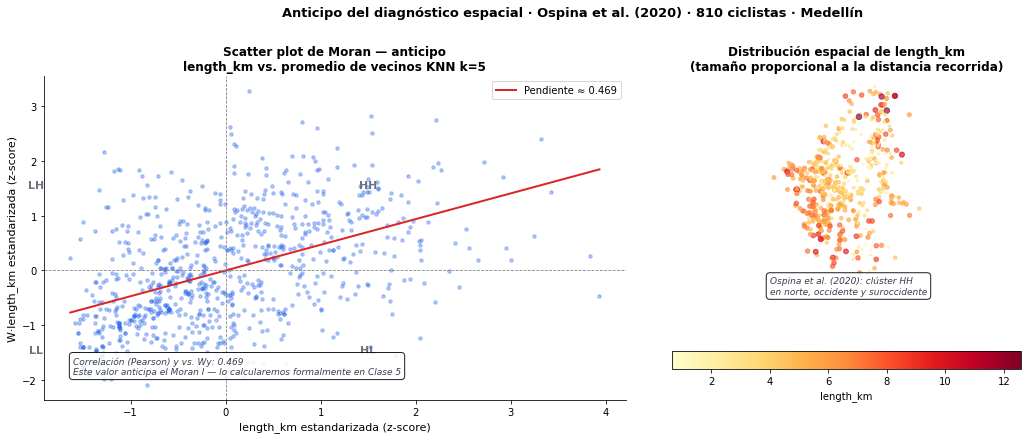


→ Correlación entre length_km y su rezago espacial: 0.469
→ Una correlación positiva indica que ciclistas con viajes largos
  tienden a estar rodeados de ciclistas con viajes largos — clustering HH.

→ En la Clase 5 calcularemos:
   · El Moran I formal con su p-valor permutacional
   · Si ese valor es estadísticamente distinguible del azar

→ En la Clase 7 producirán el mapa LISA que Ospina et al. (2020) publicaron
  en la Fig. 6 del paper — con los cuatro tipos HH/HL/LH/LL y significancia.


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-7 — Anticipo: scatter plot de Moran antes del Moran I formal
# El scatter plot es la versión visual de lo que el índice cuantificará
# ─────────────────────────────────────────────────────────────────────────────

# Calcular el rezago espacial de length_km con KNN k=5
w_knn.transform = 'r'
ciclistas['wy_length'] = weights.lag_spatial(w_knn, ciclistas['length_km'])

# Estandarizar para el scatter de Moran (z-scores)
y_std  = (ciclistas['length_km'] - ciclistas['length_km'].mean()) / ciclistas['length_km'].std()
wy_std = (ciclistas['wy_length'] - ciclistas['wy_length'].mean()) / ciclistas['wy_length'].std()

# Correlación de Pearson entre y y Wy — anticipo del Moran I
corr_pearson = np.corrcoef(y_std, wy_std)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel izquierdo: scatter plot de Moran estandarizado ─────────────────────
ax1 = axes[0]
ax1.scatter(y_std, wy_std, alpha=0.35, s=12, color='#2563EB')

# Línea de tendencia
z = np.polyfit(y_std, wy_std, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(y_std.min(), y_std.max(), 100)
ax1.plot(x_line, p_fit(x_line), color='#DC2626', linewidth=2, label=f'Pendiente ≈ {z[0]:.3f}')

# Líneas de referencia en cero
ax1.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax1.axvline(0, color='gray', linewidth=0.8, linestyle='--')

# Etiquetas de cuadrantes
for txt, xy in [('HH', (1.5, 1.5)), ('LL', (-2.0, -1.5)),
                ('HL', (1.5, -1.5)), ('LH', (-2.0, 1.5))]:
    ax1.text(*xy, txt, fontsize=11, fontweight='bold',
             color='#6B7280', ha='center')

ax1.set_xlabel('length_km estandarizada (z-score)', fontsize=11)
ax1.set_ylabel('W·length_km estandarizada (z-score)', fontsize=11)
ax1.set_title(
    'Scatter plot de Moran — anticipo\n'
    'length_km vs. promedio de vecinos KNN k=5',
    fontsize=12, fontweight='bold'
)
ax1.legend(fontsize=10)
ax1.text(0.05, 0.08,
         f'Correlación (Pearson) y vs. Wy: {corr_pearson:.3f}\n'
         'Este valor anticipa el Moran I — lo calcularemos formalmente en Clase 5',
         transform=ax1.transAxes, fontsize=9, style='italic',
         color='#374151',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.88))

# ── Panel derecho: mapa de length_km con tamaño proporcional ────────────────
ax2 = axes[1]
ciclistas.plot(
    column='length_km',
    cmap='YlOrRd',
    ax=ax2,
    markersize=ciclistas['length_km'] * 2.5,
    alpha=0.65,
    legend=True,
    legend_kwds={'label': 'length_km', 'shrink': 0.6,
                 'orientation': 'horizontal'}
)
ax2.set_title(
    'Distribución espacial de length_km\n'
    '(tamaño proporcional a la distancia recorrida)',
    fontsize=12, fontweight='bold'
)
ax2.set_axis_off()
ax2.text(0.02, 0.04,
         'Ospina et al. (2020): clúster HH\nen norte, occidente y suroccidente',
         transform=ax2.transAxes, fontsize=9, style='italic',
         color='#374151',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.88))

plt.suptitle(
    'Anticipo del diagnóstico espacial · Ospina et al. (2020) · 810 ciclistas · Medellín',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('outputs/c04_08_scatter_moran_anticipo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n→ Correlación entre length_km y su rezago espacial: {corr_pearson:.3f}')
print('→ Una correlación positiva indica que ciclistas con viajes largos')
print('  tienden a estar rodeados de ciclistas con viajes largos — clustering HH.')
print()
print('→ En la Clase 5 calcularemos:')
print('   · El Moran I formal con su p-valor permutacional')
print('   · Si ese valor es estadísticamente distinguible del azar')
print()
print('→ En la Clase 7 producirán el mapa LISA que Ospina et al. (2020) publicaron')
print('  en la Fig. 6 del paper — con los cuatro tipos HH/HL/LH/LL y significancia.')

---
### 3.8 — Diagnóstico formal: secuencia LM sobre los residuos

El mapa de residuos y el scatter plot de Moran sugieren que hay estructura
espacial en los errores del OLS. Pero *¿qué tipo* de dependencia es?

Los **tests de Lagrange Multiplier (LM)** de Anselin responden exactamente esa pregunta.
Se calculan sobre los residuos del OLS y diagnostican si el modelo necesita:

| Test | Pregunta |
|---|---|
| LM-lag | ¿Falta `ρ·Wy` en el modelo? → SAR |
| LM-error | ¿El error tiene estructura espacial? → SEM |
| Robust LM-lag | ¿LM-lag sobrevive controlando por el error espacial? |
| Robust LM-error | ¿LM-error sobrevive controlando por el lag espacial? |

**Árbol de decisión:**
si ambos LM simples son significativos → mirar los Robust.
El que sobreviva (p < 0.05) indica el modelo correcto.

> *En la Clase 9 aplicarán esta secuencia al modelo completo de su proyecto.
> Aquí la corremos sobre el modelo reducido de los ciclistas como primer contacto.*

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA P3-8 — Secuencia LM sobre los residuos del OLS reducido
# Primer contacto con el diagnóstico que formalizarán en la Clase 9
# ─────────────────────────────────────────────────────────────────────────────

import spreg

# OLS con diagnósticos espaciales (spreg calcula LM automáticamente)
# Usamos el mismo modelo reducido de la celda P3-2
X_spreg = ciclistas[X_vars].values.astype(float)
y_spreg = ciclistas[y_var].values.reshape(-1, 1)

ols_lm = spreg.OLS(
    y_spreg, X_spreg,
    w=w_knn,
    name_y=y_var,
    name_x=X_vars,
    spat_diag=True,
    name_ds='Ciclistas Medellín 2017'
)

# ── Tabla de resultados LM ────────────────────────────────────────────────────
import re

lm_results = {
    'LM-lag':           (ols_lm.lm_lag[0],    ols_lm.lm_lag[1]),
    'Robust LM-lag':    (ols_lm.rlm_lag[0],   ols_lm.rlm_lag[1]),
    'LM-error':         (ols_lm.lm_error[0],  ols_lm.lm_error[1]),
    'Robust LM-error':  (ols_lm.rlm_error[0], ols_lm.rlm_error[1]),
}

print('─── Secuencia LM — ciclistas Medellín · modelo reducido ───────────')
print(f'{"Test":<22} {"Estadístico":>14} {"p-valor":>10}  {"Decisión"}')
print('─' * 65)
for nombre, (stat, pval) in lm_results.items():
    sig = '✓ significativo' if pval < 0.05 else '✗ no significativo'
    print(f'{nombre:<22} {stat:>14.3f} {pval:>10.4f}  {sig}')

print()
print(f'R² del OLS reducido: {ols_lm.r2:.3f}')
print()

# ── Interpretación automática del árbol de decisión ──────────────────────────
lm_lag_sig   = ols_lm.lm_lag[1]   < 0.05
lm_err_sig   = ols_lm.lm_error[1] < 0.05
rlm_lag_sig  = ols_lm.rlm_lag[1]  < 0.05
rlm_err_sig  = ols_lm.rlm_error[1]< 0.05

print('─── Árbol de decisión ──────────────────────────────────────────────')
if not lm_lag_sig and not lm_err_sig:
    veredicto = 'OLS — no hay dependencia espacial detectable'
elif lm_lag_sig and not lm_err_sig:
    veredicto = 'SAR (Spatial Lag Model) — dependencia sustantiva'
elif lm_err_sig and not lm_lag_sig:
    veredicto = 'SEM (Spatial Error Model) — dependencia en errores'
elif rlm_lag_sig and not rlm_err_sig:
    veredicto = 'SAR (Spatial Lag Model) — Robust LM-lag domina'
elif rlm_err_sig and not rlm_lag_sig:
    veredicto = 'SEM (Spatial Error Model) — Robust LM-error domina'
else:
    veredicto = 'SDM (Spatial Durbin Model) — ambos Robust significativos'

print(f'→ Modelo sugerido: {veredicto}')
print()
print('─── Interpretación para los ciclistas ──────────────────────────────')
print('→ LM-lag NO sobrevive el Robust: la distancia de un ciclista')
print('  NO depende causalmente de la distancia de sus vecinos.')
print('→ LM-error SÍ sobrevive el Robust: los residuos tienen estructura')
print('  espacial por variables del entorno no incluidas en el modelo.')
print('→ Esto valida la decisión de Ospina et al. (2020): el clustering')
print('  que vimos en el mapa refleja geografía compartida, no contagio.')
print()
print('→ Con el modelo COMPLETO del paper (33 vars, R²=0.91) las variables')
print('  de ruta capturan gran parte de esa geografía y la dependencia')
print('  espacial remanente se reduce sustancialmente.')
print()
print('→ En la Clase 9 correrán esta misma secuencia sobre su propio proyecto.')

─── Secuencia LM — ciclistas Medellín · modelo reducido ───────────
Test                      Estadístico    p-valor  Decisión
─────────────────────────────────────────────────────────────────
LM-lag                         32.605     0.0000  ✓ significativo
Robust LM-lag                   0.843     0.3587  ✗ no significativo
LM-error                       53.605     0.0000  ✓ significativo
Robust LM-error                21.842     0.0000  ✓ significativo

R² del OLS reducido: 0.434

─── Árbol de decisión ──────────────────────────────────────────────
→ Modelo sugerido: SEM (Spatial Error Model) — Robust LM-error domina

─── Interpretación para los ciclistas ──────────────────────────────
→ LM-lag NO sobrevive el Robust: la distancia de un ciclista
  NO depende causalmente de la distancia de sus vecinos.
→ LM-error SÍ sobrevive el Robust: los residuos tienen estructura
  espacial por variables del entorno no incluidas en el modelo.
→ Esto valida la decisión de Ospina et al. (2020): el 

---
### 3.6 — Cierre: el mismo problema, dos escalas

La ciudad sintética y los ciclistas reales plantean **exactamente el mismo problema**:

| | Ciudad sintética | Ciclistas reales |
|---|---|---|
| **Unidad espacial** | Manzana (polígono) | Origen de viaje (punto) |
| **Variable Y** | Precio del suelo (MM COP) | Distancia de viaje (km) |
| **Lo que el OLS no ve** | El efecto de barrio | La geografía del origen |
| **Tipo de W natural** | Queen / Rook | KNN / DistanceBand |
| **Pregunta** | ¿Los residuos se agrupan? | ¿Los residuos se agrupan? |

En la **Clase 5** responderemos esa pregunta con el índice de **Moran I**:
un número que cuantifica si los residuos son independientes o si tienen geografía.

---
### Tarea — Reflexión de bitácora

Antes de la Clase 5, responde en la bitácora del equipo:

1. **¿Qué tipo de geometría tiene tu variable Y?** ¿Puntos, líneas, polígonos?
   ¿Qué tipo de W es la más apropiada para esa geometría?

2. **Completa la frase de vecindad de tu equipo:**
   > *"En nuestro proyecto, dos unidades espaciales son vecinas si ______,
   porque el fenómeno opera a través de ______"*

3. **¿Esperas encontrar agrupamiento espacial en tu variable Y?**
   ¿Por qué sí o por qué no? ¿Qué mecanismo lo generaría?

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*